In [25]:
!pip install -q sentence-transformers rapidfuzz

In [26]:
import numpy as np
import pandas as pd
import joblib
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from rapidfuzz import process, fuzz
# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [27]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')


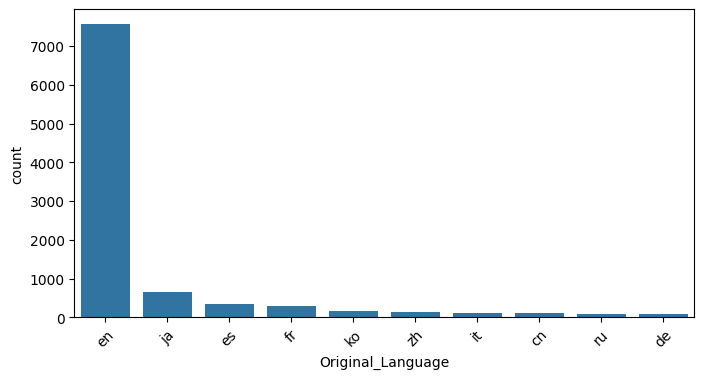

In [28]:
#Top languages
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x='Original_Language',
    order=df['Original_Language'].value_counts().head(10).index
)

plt.xticks(rotation=45)
plt.show()

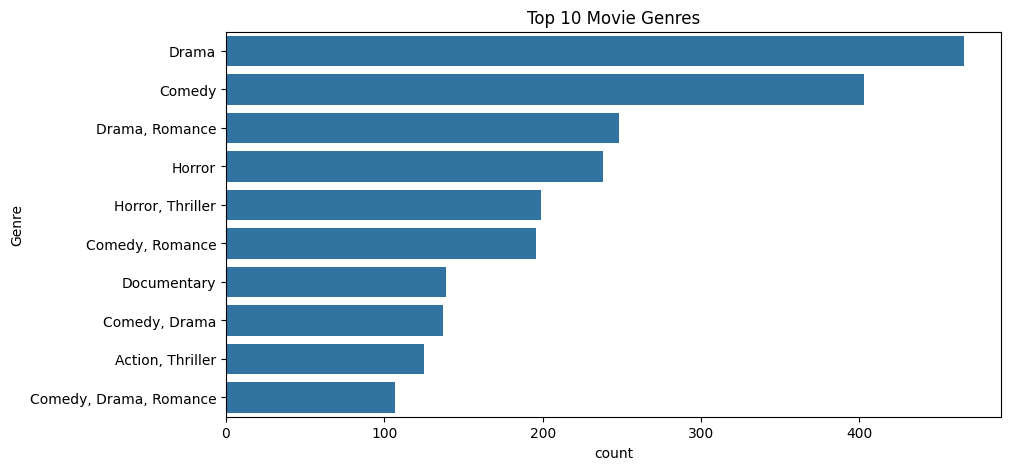

In [29]:
#Top 10 genres
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='Genre',
    order=df['Genre'].value_counts().head(10).index
)

plt.title("Top 10 Movie Genres")
plt.show()

In [30]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

In [31]:
df['Release_Year'] = df['Release_Date'].dt.year

In [32]:
df['Genre'] = df['Genre'].str.replace(',', ' ', regex=False)

In [33]:
df['Genre'] = df['Genre'].str.lower()

genre_map = {
    "Science Fiction": "science_fiction",
    "TV Movie": "tv_movie",
    "War & Politics": "war_politics"
}

for old, new in genre_map.items():
    df['Genre'] = df['Genre'].str.replace(old.lower(), new, regex=False)

df['Genre'] = df['Genre'].str.replace(",", "", regex=False)

In [34]:
df["tags"] = (
    df["Title"] + " " +
    (df["Genre"] + " ") * 10 +
    df["Overview"]
)

In [35]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [36]:
print(model)

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)


In [37]:
embeddings = model.encode(
    df["tags"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/308 [00:00<?, ?it/s]

In [38]:
embeddings.shape

(9827, 384)

In [39]:
print(embeddings[0][:10])

[-0.03355448 -0.03696038 -0.00968052  0.04615062 -0.0016066   0.01957543
  0.01857593 -0.01714683 -0.12452528 -0.00945342]


In [40]:
joblib.dump(embeddings, "movie_embeddings.pkl")

['movie_embeddings.pkl']

In [44]:
def clean_text(text):

    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z_\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [46]:
similarity = cosine_similarity(embeddings)

In [47]:
similarity.shape

(9827, 9827)

In [50]:
movie_titles = df["Title"].tolist()

In [51]:
from rapidfuzz import process, fuzz

In [62]:
def recommend(movie_name, n=5):

    match = process.extractOne(
        movie_name,
        movie_titles,
        scorer=fuzz.WRatio,
        score_cutoff=70
    )

    if match is None:
        return "Movie not found."

    movie = match[0]

    idx = df[df["Title"] == movie].index[0]

    scores = list(enumerate(similarity[idx]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for i, score in scores[1:]:
        if score < 0.50:
          continue

        m = df.iloc[i]

        recommendations.append({

            "Movie": m["Title"],

            "Similarity":
            f"{score*100:.1f}%",

            "Genre":
            m["Genre"],

            "Rating":
            m["Vote_Average"],

            "Popularity":
            round(m["Popularity"],2),

            "Release Year":
            m["Release_Year"],

            "Poster":
            m["Poster_Url"]

        })

        if len(recommendations) == n:
           break

    return movie, pd.DataFrame(recommendations)

In [63]:
idx1 = df[df["Title"]=="Avatar"].index[0]
idx2 = df[df["Title"]=="Avatar 2"].index[0]

print(similarity[idx1][idx2])

0.6595462


In [64]:
recommend("Avatar")

('Avatar',
          Movie Similarity                                        Genre  \
 0   Inuyashiki      71.6%  action  adventure  science_fiction  fantasy   
 1   Cosmic Sin      71.2%           action  adventure  science_fiction   
 2     Moonfall      70.3%           action  adventure  science_fiction   
 3   Attraction      69.1%   drama  romance  science_fiction  adventure   
 4  Pacific Rim      68.6%           action  science_fiction  adventure   
 
    Rating  Popularity  Release Year  \
 0     7.7       37.80          2018   
 1     4.2      138.80          2021   
 2     5.9      328.68          2022   
 3     6.6       26.23          2017   
 4     6.8      123.37          2013   
 
                                               Poster  
 0  https://image.tmdb.org/t/p/original/lyqkQ6y7d4...  
 1  https://image.tmdb.org/t/p/original/6Wm7P6y22U...  
 2  https://image.tmdb.org/t/p/original/odVv1sqVs0...  
 3  https://image.tmdb.org/t/p/original/uMr2lXCh8P...  
 4  https://ima

In [65]:
recommend("avatarr")

('Avatar',
          Movie Similarity                                        Genre  \
 0   Inuyashiki      71.6%  action  adventure  science_fiction  fantasy   
 1   Cosmic Sin      71.2%           action  adventure  science_fiction   
 2     Moonfall      70.3%           action  adventure  science_fiction   
 3   Attraction      69.1%   drama  romance  science_fiction  adventure   
 4  Pacific Rim      68.6%           action  science_fiction  adventure   
 
    Rating  Popularity  Release Year  \
 0     7.7       37.80          2018   
 1     4.2      138.80          2021   
 2     5.9      328.68          2022   
 3     6.6       26.23          2017   
 4     6.8      123.37          2013   
 
                                               Poster  
 0  https://image.tmdb.org/t/p/original/lyqkQ6y7d4...  
 1  https://image.tmdb.org/t/p/original/6Wm7P6y22U...  
 2  https://image.tmdb.org/t/p/original/odVv1sqVs0...  
 3  https://image.tmdb.org/t/p/original/uMr2lXCh8P...  
 4  https://ima

In [66]:
joblib.dump(df, "movies.pkl")

joblib.dump(embeddings, "movie_embeddings.pkl")

joblib.dump(similarity, "similarity.pkl")

['similarity.pkl']